In [1]:
# Cell 1: Imports & Configurations
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv
from fredapi import Fred
import timesfm

# Load environment variables
load_dotenv()

# Securely fetch the FRED API key
FRED_API_KEY = os.getenv('FRED_API_KEY')
if not FRED_API_KEY:
    raise ValueError("FRED_API_KEY not found. Please ensure your .env file is set up correctly.")

# Initialize FRED API client
fred = Fred(api_key=FRED_API_KEY)

# Configure clean, corporate plotting styles for business analysts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'figure.autolayout': True,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'lines.linewidth': 2.5,
    'font.family': 'sans-serif',
    'legend.frameon': True,
    'legend.facecolor': 'white'
})

print("✅ Libraries imported, styling configured, and FRED API initialized successfully.")

✅ Libraries imported, styling configured, and FRED API initialized successfully.


In [34]:
# Cell 2: Model Instantiation
import torch
import timesfm

print("Initializing TimesFM 2.5 model...")

# Set matmul precision for hardware acceleration (Ampere+ GPUs)
torch.set_float32_matmul_precision("high")

# Define context and horizon based on our 12-month data plan
CONTEXT_LENGTH = 512
HORIZON_LENGTH = 12

# Instantiate the 2.5 model directly from HuggingFace
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

# Compile the model with the correct forecast configuration
tfm.compile(
    timesfm.ForecastConfig(
        max_context=CONTEXT_LENGTH,
        max_horizon=HORIZON_LENGTH,
        normalize_inputs=True,              # Recommended to prevent scale instability
        use_continuous_quantile_head=True,  # Recommended for accurate quantiles
        return_backcast=True
    )
)

print(f"✅ TimesFM 2.5 instantiated and compiled successfully with a {HORIZON_LENGTH}-month horizon.")

Initializing TimesFM 2.5 model...
✅ TimesFM 2.5 instantiated and compiled successfully with a 12-month horizon.


In [35]:
# Cell 3: Load Data & Convert to Long Format
print("Loading and reshaping dataset...")

# Define the exact filename verbatim
file_path = "U20403-M - Sheet1.csv"

try:
    # Read the wide-format CSV file
    df_wide = pd.read_csv(file_path)
    print(f"✅ Successfully loaded '{file_path}' in wide format.")
    
    # Melt the dataframe from wide to long
    df_long = pd.melt(
        df_wide, 
        id_vars=['category', 'category_key'], # Keep identifiers intact
        var_name='Date_Raw',                  # The previous column headers (e.g., '1959M01')
        value_name='value'                   # The actual index values
    )
    
    # Convert the BEA 'YYYYMmm' format into proper pandas datetime objects
    # We replace 'M' with '-' to make it 'YYYY-mm', which pandas parses natively
    df_long['Date'] = pd.to_datetime(df_long['Date_Raw'].str.replace('M', '-'))
    
    # Drop the raw date string to keep it clean, sort chronologically, and drop missing values
    df_long = df_long.drop(columns=['Date_Raw']).sort_values(by=['category_key', 'Date']).dropna(subset=['value']).reset_index(drop=True)
    
    print(f"✅ Dataset successfully reshaped to long format.")
    print(f"New dataset shape: {df_long.shape[0]} rows, {df_long.shape[1]} columns.\n")
    
    # Display the first few rows to verify the transformation
    display(df_long.head())
    
except FileNotFoundError:
    print(f"❌ Error: Could not find '{file_path}'. Please ensure the file is in the same directory.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

Loading and reshaping dataset...


✅ Successfully loaded 'U20403-M - Sheet1.csv' in wide format.
✅ Dataset successfully reshaped to long format.
New dataset shape: 324013 rows, 4 columns.



,category,category_key,value,Date
0,Expenditures abroad by U.S. residents,DABDRA,247.099,1959-01-01
1,Expenditures abroad by U.S. residents,DABDRA,253.032,1959-02-01
2,Expenditures abroad by U.S. residents,DABDRA,261.725,1959-03-01
3,Expenditures abroad by U.S. residents,DABDRA,258.047,1959-04-01
4,Expenditures abroad by U.S. residents,DABDRA,245.510,1959-05-01


In [36]:
# Cell 4: Clean & Align (Updated for Long Format)
print("Cleaning and aligning datasets...")

# 1. Process DVAPRA from the reshaped long dataset
df_target = df_long[df_long['category_key'] == 'DVAPRA'].copy()
df_target['Date'] = pd.to_datetime(df_target['Date']) # Ensure Date is datetime
df_target = df_target[['Date', 'value']].rename(columns={'value': 'DVAPRA'}).set_index('Date')

# Force a strict monthly start frequency
df_target = df_target.resample('MS').first()

# 2. Fetch Brent Crude dynamically from FRED
print("Fetching Brent Crude (POILBREUSDM) from FRED API...")
brent_series = fred.get_series('POILBREUSDM')
df_brent = pd.DataFrame({'Brent_Crude': brent_series})
df_brent.index.name = 'Date'
df_brent.index = pd.to_datetime(df_brent.index)
df_brent = df_brent.resample('MS').mean()

# 3. Merge the datasets (FIXED: Using df_target here)
df_clean = pd.merge(df_target, df_brent, left_index=True, right_index=True, how='outer')

# 4. Handle gaps and trimming
df_clean['Brent_Crude'] = df_clean['Brent_Crude'].ffill()

# Trim to when BOTH series have data
first_valid_date = max(df_clean['DVAPRA'].first_valid_index(), df_clean['Brent_Crude'].first_valid_index())
df_clean = df_clean.loc[first_valid_date:]

# Ragged Edge preservation: Only drop if Brent is missing
df_clean = df_clean[df_clean['Brent_Crude'].notna()]

print("✅ Data aligned successfully. Outer join preserved fresh covariate data.")
print(f"Final dataset covers {df_clean.index[0].date()} to {df_clean.index[-1].date()} ({len(df_clean)} months).")

# Display the final 4 months to verify the "Ragged Edge" (Brent exists while DVAPRA is NaN)
display(df_clean.tail(4))

Cleaning and aligning datasets...
Fetching Brent Crude (POILBREUSDM) from FRED API...
✅ Data aligned successfully. Outer join preserved fresh covariate data.
Final dataset covers 1992-01-01 to 2026-03-01 (411 months).


,DVAPRA,Brent_Crude
Date,,
2025-12-01,286.341,61.810909
2026-01-01,284.994,64.594091
2026-02-01,277.634,69.409500
2026-03-01,275.77,99.405000


In [37]:
# %%
# Cell 5: Extract Historical Trajectories
print("Extracting historical Brent Crude trajectories...")

# Define the start dates for the first 12 months of our designated periods
# Bear: 2007Q1 (Jan 2007), Bull: 2010Q3 (July 2010), Base: 2021Q1 (Jan 2021)
scenario_dates = {
    'Bear': '2007-01-01',
    'Bull': '2010-07-01',
    'Base': '2021-01-01'
}

# Dictionary to hold the 12-month growth multipliers
historical_trajectories = {}

for scenario, start_date in scenario_dates.items():
    # Extract the 12-month slice starting from the designated historical date
    
    # 1. Grab 13 months of history from the actual Brent Crude data (Anchor + 12 Future Months)
    end_date = pd.to_datetime(start_date) + pd.DateOffset(months=12)
    slice_13m = df_clean.loc[start_date:end_date, 'Brent_Crude']
    
    # 2. Divide by the anchor (Index 0), but then slice off the anchor [1:] 
    # This leaves exactly 12 multipliers of actual movement to apply to March onward
    trajectory_multiplier = (slice_13m.values / slice_13m.values[0])[1:]
    historical_trajectories[scenario] = trajectory_multiplier
    
    print(f"✅ {scenario} trajectory extracted (Starts: {start_date}).")

# Preview the multipliers for the first few months of each scenario
print("\nMultiplier Preview (Months 1-3):")
for scenario, multipliers in historical_trajectories.items():
    print(f"{scenario}: {multipliers[:3].round(3)}")

Extracting historical Brent Crude trajectories...
✅ Bear trajectory extracted (Starts: 2007-01-01).
✅ Bull trajectory extracted (Starts: 2010-07-01).
✅ Base trajectory extracted (Starts: 2021-01-01).

Multiplier Preview (Months 1-3):
Bear: [1.064 1.144 1.242]
Bull: [1.023 1.036 1.108]
Base: [1.129 1.191 1.187]


In [38]:
# Cell 6: TimesFM Brent Forecast & Scenario Blending
print("Executing TimesFM baseline forecast for Brent Crude...")

# 1. Prepare the Brent Crude context tensor (up to April 2026)
# TimesFM expects the context data as a list of 1D numpy arrays
brent_history = df_clean['Brent_Crude'].values
context_data = brent_history[-CONTEXT_LENGTH:] # Truncate to our 512 context limit

# 2. Run the TimesFM 2.5 forecast for Brent Crude
# Explicitly pass horizon and inputs. It returns point and quantile arrays.
point_forecast, quantile_forecast = tfm.forecast(
    horizon=HORIZON_LENGTH,
    inputs=[context_data]
)

# Extract the 1D point forecast array for our single scenario
timesfm_baseline = point_forecast[0][-HORIZON_LENGTH:]

# 3. Blend the TimesFM forecast with our Historical Trajectories
print("\nBlending TimesFM baseline with historical trajectories...")

# --- SET YOUR EMPHASIS WEIGHTS HERE ---
# 80% emphasis on the historical periods, 20% emphasis on TimesFM's current reading
HISTORICAL_WEIGHT = 0.50 
TIMESFM_WEIGHT = 1.0 - HISTORICAL_WEIGHT
print(f"Weighting Strategy: {HISTORICAL_WEIGHT*100}% Historical Shape / {TIMESFM_WEIGHT*100}% TimesFM Baseline")

# Generate the future datetime index (May 2026 to April 2027)
future_dates = pd.date_range(start=df_clean.index[-1] + pd.DateOffset(months=1), periods=HORIZON_LENGTH, freq='MS')
df_scenarios = pd.DataFrame(index=future_dates)
baseline_price = brent_history[-1]

# Apply the blend for each scenario
for scenario, multipliers in historical_trajectories.items():
    # A. Calculate the pure historical projection (Baseline * Multiplier)
    pure_historical = baseline_price * multipliers
    
    # B. The Blended Formula
    # Combine the TimesFM prediction with the historical shape based on your weights
    blended_forecast = (pure_historical * HISTORICAL_WEIGHT) + (timesfm_baseline * TIMESFM_WEIGHT)
    
    df_scenarios[scenario] = blended_forecast

print("\n✅ 12-Month Blended Scenarios generated successfully.")
display(df_scenarios)

Executing TimesFM baseline forecast for Brent Crude...

Blending TimesFM baseline with historical trajectories...
Weighting Strategy: 50.0% Historical Shape / 50.0% TimesFM Baseline

✅ 12-Month Blended Scenarios generated successfully.


,Bear,Bull,Base
2026-04-01,103.182354,101.142783,106.445210
2026-05-01,103.858254,98.509005,106.210046
2026-06-01,104.264957,97.621802,101.515443
2026-07-01,101.141727,96.101191,100.926362
2026-08-01,101.466002,97.850825,103.228711
2026-09-01,105.316363,99.972599,102.852026
2026-10-01,100.048373,103.916187,98.546109
2026-11-01,104.159955,110.108178,101.424795
2026-12-01,109.055198,115.330939,109.293970
2027-01-01,117.662995,109.065563,105.900989


Generating Deliverable 1: Brent Crude Scenarios...


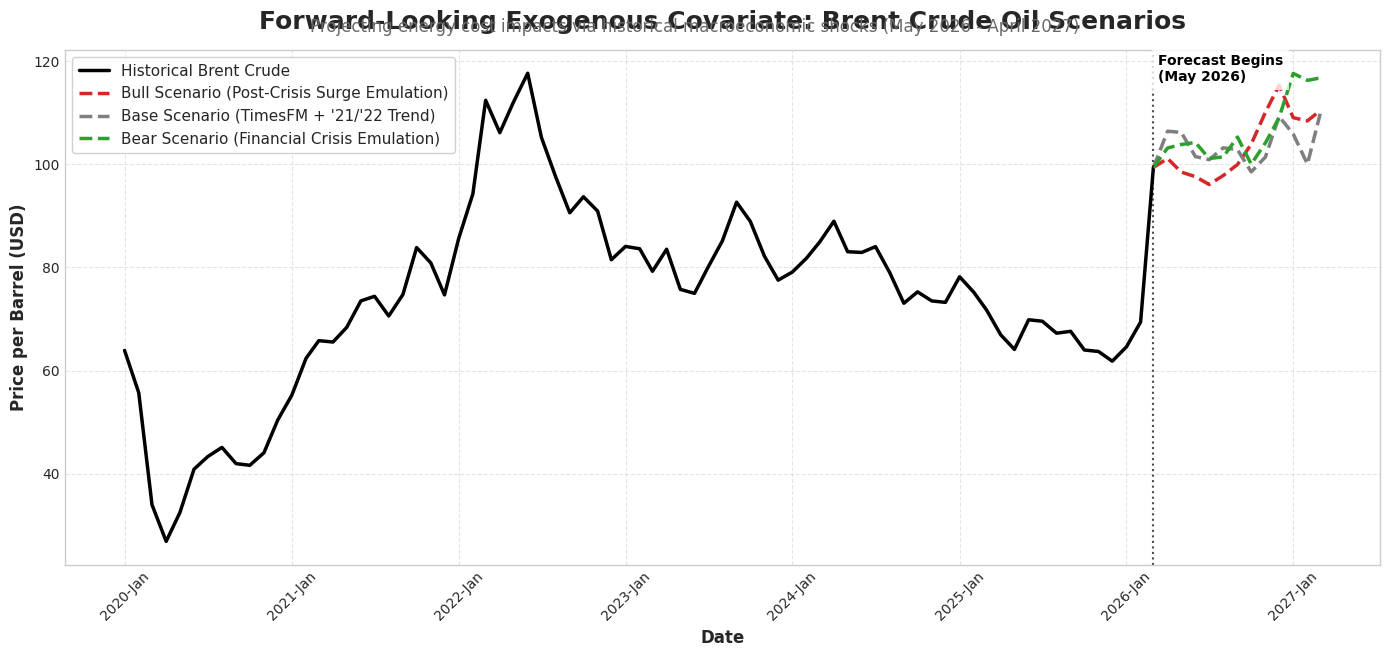

In [39]:
# Cell 7: Deliverable 1 - Scenario Visualization
print("Generating Deliverable 1: Brent Crude Scenarios...")

# Create a figure with our pre-defined corporate styling
plt.figure(figsize=(14, 7))

# 1. Plot the Historical Data (Cropped from 2020 onward for better visual scaling)
historical_start = '2020-01-01'
historical_slice = df_clean.loc[historical_start:]
plt.plot(historical_slice.index, historical_slice['Brent_Crude'], 
         label='Historical Brent Crude', color='black', linewidth=2.5)

# 2. Bridge the gap for plotting
# To make the lines connect seamlessly, we prepend the final historical date/price to our forecast data
last_date = df_clean.index[-1]
last_price = df_clean['Brent_Crude'].iloc[-1]

# Create a temporary plotting dataframe that starts in April 2026
plot_scenarios = df_scenarios.copy()
plot_scenarios.loc[last_date] = [last_price, last_price, last_price]
plot_scenarios = plot_scenarios.sort_index()

# 3. Plot the Three Scenarios with Business-Friendly Colors
# Bull = High Oil (Inflationary Risk -> Red)
plt.plot(plot_scenarios.index, plot_scenarios['Bull'], 
         label='Bull Scenario (Post-Crisis Surge Emulation)', color='#d62728', linestyle='--', linewidth=2.5)

# Base = Baseline (Supply Chain Baseline -> Grey)
plt.plot(plot_scenarios.index, plot_scenarios['Base'], 
         label="Base Scenario (TimesFM + '21/'22 Trend)", color='#7f7f7f', linestyle='--', linewidth=2.5)

# Bear = Low Oil (Demand Destruction -> Green)
plt.plot(plot_scenarios.index, plot_scenarios['Bear'], 
         label='Bear Scenario (Financial Crisis Emulation)', color='#2ca02c', linestyle='--', linewidth=2.5)

# 4. Add Contextual Formatting
# Vertical line to clearly separate history from forecast
plt.axvline(x=last_date, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
plt.text(last_date + pd.DateOffset(days=10), plt.ylim()[1] * 0.95, 'Forecast Begins\n(May 2026)', 
         fontsize=10, fontweight='bold', color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Titles and Labels
plt.title('Forward-Looking Exogenous Covariate: Brent Crude Oil Scenarios', fontsize=18, pad=15)
plt.suptitle('Projecting energy cost impacts via historical macroeconomic shocks (May 2026 - April 2027)', fontsize=12, color='dimgrey', y=0.92)
plt.ylabel('Price per Barrel (USD)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')

# Date Formatting on X-Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.xticks(rotation=45)

# Clean Legend and Grid
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Render Deliverable
plt.tight_layout()
plt.show()

In [40]:
# Cell 8: Prepare TimesFM Tensors (Ragged Edge / Staggered Release Update)
print("Preparing TimesFM tensors with dynamic ragged-edge stitching...")

# 1. Isolate the two series and find their true endpoints
# (Assuming your cleaning step allowed DVAPRA to have NaNs at the end while keeping fresh Brent data)
dvapra_series = df_clean['DVAPRA'].dropna()
brent_series = df_clean['Brent_Crude'].dropna()

target_last_date = dvapra_series.index[-1]
brent_last_date = brent_series.index[-1]

print(f"Target (DVAPRA) history ends: {target_last_date.strftime('%Y-%b')}")
print(f"Covariate (Brent) history ends: {brent_last_date.strftime('%Y-%b')}")

# 2. Extract Target Context
target_context = dvapra_series.values[-CONTEXT_LENGTH:]
actual_context_len = len(target_context)

# 3. Extract Covariate Context (Strictly aligned to the Target's timeline)
# We slice Brent up to the exact date DVAPRA ends so the histories match perfectly
covariate_context = brent_series.loc[:target_last_date].values[-actual_context_len:]

# 4. Extract Known Future Covariates (The "Ragged Edge")
if brent_last_date > target_last_date:
    # Grab the actual Brent prices that occurred AFTER the last known DVAPRA date
    known_future_brent = brent_series.loc[target_last_date + pd.DateOffset(months=1):].values
    known_future_months = len(known_future_brent)
    print(f"✅ Found {known_future_months} month(s) of newer Brent actuals. Locking these in as true future covariates.")
else:
    known_future_brent = np.array([])
    known_future_months = 0

# 5. Build the Covariate Tensors for each Scenario
covariate_tensors = {}

for scenario in ['Bull', 'Base', 'Bear']:
    # We need exactly 12 months of future data (HORIZON_LENGTH). 
    # Subtract the months we already know from actual Brent data so we don't over-forecast.
    simulated_months_needed = HORIZON_LENGTH - known_future_months
    
    # Slice the scenario forecast to only grab the remaining needed months
    scenario_future = df_scenarios[scenario].values[:simulated_months_needed]
    
    # Stitch it all together: History + Known Actuals + Simulated Future
    full_covariate_array = np.concatenate([covariate_context, known_future_brent, scenario_future])
    
    covariate_tensors[scenario] = {
        "brent_crude": [full_covariate_array.astype(np.float32)]
    }

# 6. Format the target input tensor
timesfm_target_input = [target_context.astype(np.float32)]

print("\n✅ All tensors successfully stitched and formatted for TimesFM 2.5 XReg API.")

Preparing TimesFM tensors with dynamic ragged-edge stitching...
Target (DVAPRA) history ends: 2026-Mar
Covariate (Brent) history ends: 2026-Mar

✅ All tensors successfully stitched and formatted for TimesFM 2.5 XReg API.


In [41]:
# Cell 9: Execute Forecasts
print("Executing TimesFM forecasts for DVAPRA across all scenarios...")

# Generate the future datetime index (May 2026 to April 2027)
future_dates = pd.date_range(start=df_clean.index[-1] + pd.DateOffset(months=1), periods=HORIZON_LENGTH, freq='MS')

# Initialize a clean DataFrame to store the final DVAPRA predictions
df_dvapra_forecast = pd.DataFrame(index=future_dates)

# Loop through our prepared covariate tensors (Bull, Base, Bear)
for scenario, dynamic_cov in covariate_tensors.items():
    print(f"Running {scenario} scenario forecast...")
    
    # Execute the forecast utilizing the specific forecast_with_covariates method
    # It returns two items: the combined forecast, and the pure regression forecast.
    # We only want the combined forecast (index 0).
    point_forecast, _ = tfm.forecast_with_covariates(
        inputs=timesfm_target_input,
        dynamic_numerical_covariates=dynamic_cov, # Pass the specific scenario's future oil prices
        xreg_mode="xreg + timesfm" # Recommended mode: model removes linear trend first, then forecasts residual
    )
    
    # Extract the 1D point forecast array (index 0 because we passed a batch of 1 series)
    dvapra_pred = point_forecast[0]
    
    # Store the results in our DataFrame
    df_dvapra_forecast[scenario] = dvapra_pred

print("\n✅ All 12-month DVAPRA forecasts generated successfully!")
display(df_dvapra_forecast)

Executing TimesFM forecasts for DVAPRA across all scenarios...
Running Bull scenario forecast...


Running Base scenario forecast...
Running Bear scenario forecast...

✅ All 12-month DVAPRA forecasts generated successfully!


,Bull,Base,Bear
2026-04-01,267.982208,274.645813,270.545349
2026-05-01,260.231293,269.909241,266.953735
2026-06-01,257.531616,262.424774,265.880096
2026-07-01,252.152771,258.216614,258.487244
2026-08-01,251.285950,258.044373,255.829193
2026-09-01,252.325317,255.943909,259.040863
2026-10-01,257.171204,250.422607,252.310501
2026-11-01,263.613953,252.701508,256.138794
2026-12-01,270.407837,262.821106,262.521057
2027-01-01,262.125763,258.148804,272.930206


In [42]:
# Cell 12: Interactive Plotly Dashboards
import plotly.graph_objects as go
import pandas as pd

print("Generating Interactive Plotly Dashboards...")

# --- Global Settings & Data Prep ---
historical_start = '2006-01-01'
historical_slice = df_clean.loc[historical_start:].copy()

# Force historical data into strict floats
historical_slice['Brent_Crude'] = pd.to_numeric(historical_slice['Brent_Crude'], errors='coerce')
historical_slice['DVAPRA'] = pd.to_numeric(historical_slice['DVAPRA'], errors='coerce')

last_date = pd.to_datetime(historical_slice.index[-1])
last_brent = float(historical_slice['Brent_Crude'].iloc[-1])
last_dvapra = float(historical_slice['DVAPRA'].iloc[-1])

# Bridge the data for Brent Crude (Covariate)
plot_brent = df_scenarios.copy()
plot_brent.loc[last_date] = [last_brent, last_brent, last_brent]
plot_brent = plot_brent.sort_index()
plot_brent.index = pd.to_datetime(plot_brent.index)
for col in plot_brent.columns:
    plot_brent[col] = pd.to_numeric(plot_brent[col], errors='coerce')

# Bridge the data for DVAPRA (Target)
plot_dvapra = df_dvapra_forecast.copy()
plot_dvapra.loc[last_date] = [last_dvapra, last_dvapra, last_dvapra]
plot_dvapra = plot_dvapra.sort_index()
plot_dvapra.index = pd.to_datetime(plot_dvapra.index)
for col in plot_dvapra.columns:
    plot_dvapra[col] = pd.to_numeric(plot_dvapra[col], errors='coerce')

# ==========================================
# CHART 1: BRENT CRUDE SCENARIOS
# ==========================================
fig1 = go.Figure()

# Add Historical Line
fig1.add_trace(go.Scatter(x=historical_slice.index, y=historical_slice['Brent_Crude'],
                          mode='lines', name='Historical Brent Crude',
                          line=dict(color='black', width=3),
                          hovertemplate='%{x|%b %Y}: $%{y:.2f}<extra></extra>'))

# Add Forecast Scenarios
fig1.add_trace(go.Scatter(x=plot_brent.index, y=plot_brent['Bull'], mode='lines', 
                          name='Bull Scenario (Post-Crisis Surge Emulation)', 
                          line=dict(color='#d62728', width=3, dash='dash'), hovertemplate='%{x|%b %Y}: $%{y:.2f}<extra></extra>'))
fig1.add_trace(go.Scatter(x=plot_brent.index, y=plot_brent['Base'], mode='lines', 
                          name="Base Scenario (TimesFM + '21/'22 Trend)", 
                          line=dict(color='#7f7f7f', width=3, dash='dash'), hovertemplate='%{x|%b %Y}: $%{y:.2f}<extra></extra>'))
fig1.add_trace(go.Scatter(x=plot_brent.index, y=plot_brent['Bear'], mode='lines', 
                          name='Bear Scenario (Financial Crisis Emulation)', 
                          line=dict(color='#2ca02c', width=3, dash='dash'), hovertemplate='%{x|%b %Y}: $%{y:.2f}<extra></extra>'))

# Formatting
fig1.add_vline(x=last_date, line_width=2, line_dash="dot", line_color="black")
fig1.add_annotation(x=last_date + pd.DateOffset(days=15), y=1.0, yref='paper',
                    text="Forecast Begins", showarrow=False, font=dict(color="black", size=12), bgcolor="rgba(255,255,255,0.8)")

fig1.update_layout(title="<b>Forward-Looking Exogenous Covariate: Brent Crude Scenarios</b><br><sup>Projecting energy cost impacts via historical macroeconomic shocks</sup>",
                   yaxis_title="<b>Price per Barrel (USD)</b>", xaxis_title="<b>Date</b>",
                   template="plotly_white", hovermode="x unified", legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
                   height=600)
fig1.show()


# ==========================================
# CHART 2: DVAPRA TARGET FORECAST
# ==========================================
fig2 = go.Figure()

# Add Historical Line
fig2.add_trace(go.Scatter(x=historical_slice.index, y=historical_slice['DVAPRA'],
                          mode='lines', name='Historical DVAPRA (Tech/Media PCE)',
                          line=dict(color='black', width=3),
                          hovertemplate='%{x|%b %Y}: %{y:.2f}<extra></extra>'))

# Add Forecast Scenarios
fig2.add_trace(go.Scatter(x=plot_dvapra.index, y=plot_dvapra['Bear'], mode='lines', 
                          name='Bear Scenario (High Energy Cost / High Inflation)', 
                          line=dict(color='#d62728', width=3), hovertemplate='%{x|%b %Y}: %{y:.2f}<extra></extra>'))
fig2.add_trace(go.Scatter(x=plot_dvapra.index, y=plot_dvapra['Base'], mode='lines', 
                          name='Base Scenario (Current Trajectory)', 
                          line=dict(color='#7f7f7f', width=3), hovertemplate='%{x|%b %Y}: %{y:.2f}<extra></extra>'))
fig2.add_trace(go.Scatter(x=plot_dvapra.index, y=plot_dvapra['Bull'], mode='lines', 
                          name='Bull Scenario (Low Energy Cost / Muted Inflation)', 
                          line=dict(color='#2ca02c', width=3), hovertemplate='%{x|%b %Y}: %{y:.2f}<extra></extra>'))

# Formatting
fig2.add_vline(x=last_date, line_width=2, line_dash="dot", line_color="black")
fig2.add_annotation(x=last_date + pd.DateOffset(days=15), y=1.0, yref='paper',
                    text="Forecast Begins", showarrow=False, font=dict(color="black", size=12), bgcolor="rgba(255,255,255,0.8)")

fig2.update_layout(title="<b>DVAPRA 12-Month Forecast: Impact of Energy Market Scenarios</b><br><sup>Personal Consumption Expenditures (Tech/Media Equipment) predicated on Brent Crude</sup>",
                   yaxis_title="<b>Index Level</b>", xaxis_title="<b>Date</b>",
                   template="plotly_white", hovermode="x unified", legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
                   height=600)
fig2.show()

Generating Interactive Plotly Dashboards...
